## Qualitative comparison

In [1]:
import os
#virtually move to parent directory
os.chdir("..")

import torch
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt

import clip
import utils
import data_utils
import similarity
from experiments import text_colorings

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [ ]:
# Change this to select which figure is plotted
figure = 'fig7b'

settings = {'fig1a': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": [46, 10, 242, 206]}, 
            'fig1b': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": [1203, 1731, 683, 185]},
            'fig6a': {"target_name":'resnet18_places', "target_layer": 'layer4', "neurons_to_display": "NetDissect"},
            'fig6b': {"target_name":'resnet18_places', "target_layer": 'layer4', "neurons_to_display": "CLIP-Dissect"},
            'fig7a': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": "NetDissect"},
            'fig7b': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": "CLIP-Dissect"},
            'fig9a': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": "NetDissect"},
            'fig9b': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": "CLIP-Dissect"},
           }

target_name = settings[figure]["target_name"]
target_layer = settings[figure]["target_layer"]
neurons_to_display = settings[figure]["neurons_to_display"]

clip_name = 'ViT-B/16'
d_probe = 'imagenet_broden'
concept_set = 'data/20k.txt'
batch_size = 200
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Quantization

In [11]:
import quantization_utils_awq

# Quantization settings
quantize_enabled = True  # Set to False to disable quantization
quantization_bits = 8    # INT8 quantization
quantization_group_size = 0  # 0 = per-channel, otherwise group-wise

if quantize_enabled:
    target_model_to_use = quantization_utils_awq.quantize_given_mdodel(
        target_name = target_name,
        quantization_bits = quantization_bits,
        quantization_group_size = quantization_group_size,
        device = device,
    )
else:
    print(f"Quantization disabled. Using original {target_name} model.")
    target_model_to_use = None  # Will load default in save_activations

Loading resnet50 model for quantization...
Quantizing resnet50 with 8-bit AWQ quantization...
Quantized model saved to saved_activations/resnet50_quantized.pt
Model quantized successfully!
Model size statistics:
  INT8 parameters: 24.32 MB
  FP32 equivalent: 0.20 MB
  Compression ratio: 0.01x


In [12]:
def save_activations_with_quantization(clip_name, target_name, target_model_to_use, target_layers, d_probe, concept_set, pool_mode, save_dir, batch_size, device):
    # Load models
    clip_model, clip_preprocess = clip.load(clip_name, device=device)

    if quantize_enabled and target_model_to_use is not None:
        # Use quantized model
        target_model = target_model_to_use
        target_preprocess = data_utils.get_target_model(target_name, device)[1]  # Get preprocessor only
    else:
        # Load default model
        target_model, target_preprocess = data_utils.get_target_model(target_name, device)

    # Setup data
    data_c = data_utils.get_data(d_probe, clip_preprocess)
    data_t = data_utils.get_data(d_probe, target_preprocess)

    with open(concept_set, 'r') as f: 
        words = (f.read()).split('\n')

    # Ignore empty lines
    words = [i for i in words if i != ""]

    # Generate text embeddings
    text = clip.tokenize(["{}".format(word) for word in words]).to(device)

    # Get save names
    save_names = utils.get_save_names(
        clip_name=clip_name,
        target_name=target_name,
        target_layer='{}',
        d_probe=d_probe,
        concept_set=concept_set,
        pool_mode=pool_mode,
        save_dir=save_dir
    )

    target_save_name, clip_save_name, text_save_name = save_names

    # Save features using quantized model (if enabled)
    print("Saving CLIP text features...")
    utils.save_clip_text_features(clip_model, text, text_save_name, batch_size)

    print("Saving CLIP image features...")
    utils.save_clip_image_features(clip_model, data_c, clip_save_name, batch_size, device)

    print(f"Saving target activations from {'quantized ' if quantize_enabled else ''}model...")
    utils.save_target_activations(
        target_model,
        data_t,
        target_save_name,
        target_layers,
        batch_size,
        device,
        pool_mode
    )

    print("Activation extraction complete!")


## Run CLIP-Dissect

In [13]:
save_activations_with_quantization(clip_name = clip_name, 
                       target_name = target_name, 
                       target_model_to_use=target_model_to_use, 
                       target_layers = [target_layer], 
                       d_probe = d_probe, 
                       concept_set = concept_set, 
                       batch_size = batch_size, 
                       device = device, 
                       pool_mode=pool_mode, 
                       save_dir = save_dir
                    )

Saving CLIP text features...
Saving CLIP image features...
Saving target activations from quantized model...


100%|██████████| 337/337 [01:15<00:00,  4.49it/s]


Activation extraction complete!


In [14]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn, device=device)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_features = torch.load(clip_save_name, map_location='cpu').floa

torch.Size([1024, 20000])


## Visualize

In [15]:
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

get_color = text_colorings.get_coloring(figure)

name_conversion = {'resnet50':'resnet50_imagenet', 'resnet18_places':'resnet18_places365'}
ood_names = {'resnet50':'p', 'resnet18_places': 'i'}

In [16]:
# Load Network Dissection results
netdissect_res = pd.read_csv('data/NetDissect_results/{}_{}.csv'.format(name_conversion[target_name],
                                                                       target_layer))
nd_ious = netdissect_res['score'].values
nd_labels = netdissect_res['label'].values

#Load MILAN results
milan_base = pd.read_csv('data/MILAN_results/m_base_{}.csv'.format(name_conversion[target_name]))
if target_name == 'resnet50':
    milan_ood = pd.read_csv('data/MILAN_results/m_places365_{}.csv'.format(name_conversion[target_name]))
elif target_name == 'resnet18_places':
    milan_ood = pd.read_csv('data/MILAN_results/m_imagenet_{}.csv'.format(name_conversion[target_name]))
    
milan_base = milan_base[milan_base['layer']==target_layer]
milan_base = milan_base.sort_values(by=['unit'])
milan_base = list(milan_base['description'])

milan_ood = milan_ood[milan_ood['layer']==target_layer]
milan_ood = milan_ood.sort_values(by=['unit'])
milan_ood = list(milan_ood['description'])

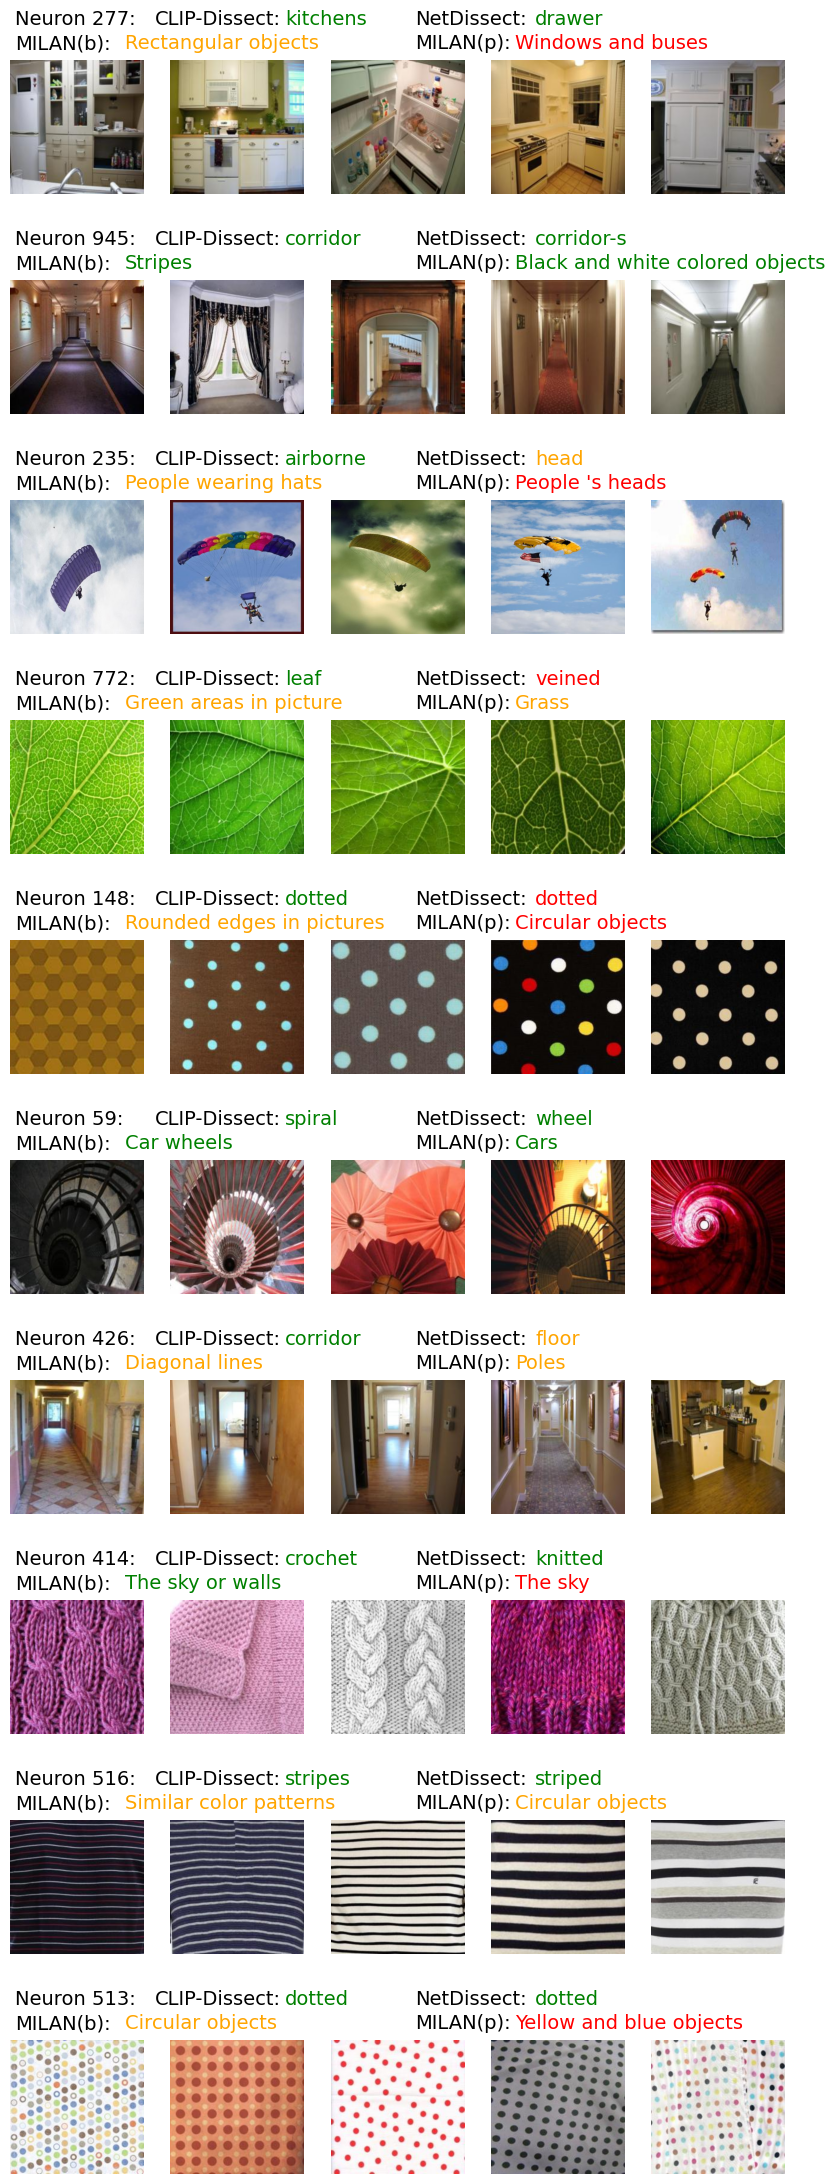

In [17]:
# Calculate which neurons to show
if type(neurons_to_display)==list:
    ids_to_check = neurons_to_display
if neurons_to_display == "CLIP-Dissect":
    ids_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
elif neurons_to_display == "NetDissect":
    ids_to_check = torch.sort(torch.tensor(nd_ious), descending=True)[1][:10]

    
#plot figures
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(ids_to_check)*2.2])
subfigs = fig.subfigures(nrows=len(ids_to_check), ncols=1)
for j, orig_id in enumerate(ids_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size, color=get_color("clip", j))
    subfig.text(0.53 ,0.96, "NetDissect:", size=font_size)
    subfig.text(0.65 ,0.96, nd_labels[orig_id], size=font_size, color=get_color("nd", j))
    
    subfig.text(0.13, 0.85, "MILAN(b):", size=font_size)
    subfig.text(0.24, 0.85, milan_base[orig_id], size=font_size, color=get_color("milan_b", j))
    
    subfig.text(0.53, 0.85, "MILAN({}):".format(ood_names[target_name]), size=font_size)
    subfig.text(0.63, 0.85, milan_ood[orig_id], size=font_size, color=get_color("milan_ood", j))
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()